# PIRVN — Deep Neural Network for Price Prediction

In [1]:
import json
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.feature_extraction.text import HashingVectorizer
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [2]:
data_dir = Path("../phase2_curation/curated_data")

def load_data(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        records = json.load(f)
    texts = [r["full"] for r in records]
    prices = [r["price"] for r in records]
    return texts, prices

train_texts, train_prices = load_data(data_dir / "train.json")
test_texts, test_prices = load_data(data_dir / "test.json")

print(f"Train samples : {len(train_texts)}")
print(f"Test  samples : {len(test_texts)}")
print(f"Price range (train): {min(train_prices):,.0f} – {max(train_prices):,.0f} VND")

Train samples : 9428
Test  samples : 1768
Price range (train): 500,000 – 49,990,000 VND


In [3]:
class ResidualBlock(nn.Module):
    """Linear -> LayerNorm -> ReLU -> Dropout -> Linear -> LayerNorm + skip connection."""

    def __init__(self, hidden_size: int, dropout_prob: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
        )
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = self.block(x)
        out += residual  # skip connection
        return self.relu(out)

In [4]:
class DeepNeuralNetwork(nn.Module):
    """Deep residual network for scalar price regression."""

    def __init__(
        self,
        input_size: int,
        num_layers: int = 10,
        hidden_size: int = 4096,
        dropout_prob: float = 0.2,
    ):
        super().__init__()

        # Input projection
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
        )

        # Residual blocks (num_layers - 2 so that total depth ≈ num_layers)
        self.residual_blocks = nn.ModuleList(
            [ResidualBlock(hidden_size, dropout_prob) for _ in range(num_layers - 2)]
        )

        # Scalar output
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_layer(x)
        for block in self.residual_blocks:
            x = block(x)
        return self.output_layer(x)

In [5]:
# --- Vectorization ---
N_FEATURES = 3000
vectorizer = HashingVectorizer(n_features=N_FEATURES, stop_words=None, binary=True)

X_train = vectorizer.fit_transform(train_texts).toarray().astype(np.float32)
X_test  = vectorizer.transform(test_texts).toarray().astype(np.float32)

# --- Log-transform prices ---
y_train_raw = np.array(train_prices, dtype=np.float32)
y_test_raw  = np.array(test_prices,  dtype=np.float32)

y_train_log = np.log(y_train_raw + 1)
y_test_log  = np.log(y_test_raw  + 1)

# --- Normalize log prices ---
Y_MEAN = float(y_train_log.mean())
Y_STD  = float(y_train_log.std())

y_train_norm = (y_train_log - Y_MEAN) / Y_STD
y_test_norm  = (y_test_log  - Y_MEAN) / Y_STD

print(f"Y_MEAN = {Y_MEAN:.6f}")
print(f"Y_STD  = {Y_STD:.6f}")

# --- TensorDatasets & DataLoaders ---
BATCH_SIZE = 256

train_dataset = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train_norm).unsqueeze(1),
)
test_dataset = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test_norm).unsqueeze(1),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Y_MEAN = 15.653934
Y_STD  = 1.151837

Train batches: 37
Test  batches: 7


In [6]:
# --- Device ---
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# --- Model, loss, optimiser, scheduler ---
EPOCHS = 20

model = DeepNeuralNetwork(
    input_size=N_FEATURES,
    num_layers=5,
    hidden_size=512,
    dropout_prob=0.4,
).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")

# --- Training loop ---
for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(X_batch)

    scheduler.step()
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch:02d}/{EPOCHS}  |  Train MSE (normalised): {epoch_loss:.6f}")

Using device: cpu
Model params: 3,120,129


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01/20  |  Train MSE (normalised): 4.402191
Epoch 02/20  |  Train MSE (normalised): 0.572586
Epoch 03/20  |  Train MSE (normalised): 0.380491
Epoch 04/20  |  Train MSE (normalised): 0.292830
Epoch 05/20  |  Train MSE (normalised): 0.247505
Epoch 06/20  |  Train MSE (normalised): 0.200809
Epoch 07/20  |  Train MSE (normalised): 0.175736
Epoch 08/20  |  Train MSE (normalised): 0.150921
Epoch 09/20  |  Train MSE (normalised): 0.130525
Epoch 10/20  |  Train MSE (normalised): 0.115326
Epoch 11/20  |  Train MSE (normalised): 0.101091
Epoch 12/20  |  Train MSE (normalised): 0.089845
Epoch 13/20  |  Train MSE (normalised): 0.081989
Epoch 14/20  |  Train MSE (normalised): 0.075880
Epoch 15/20  |  Train MSE (normalised): 0.069602
Epoch 16/20  |  Train MSE (normalised): 0.066648
Epoch 17/20  |  Train MSE (normalised): 0.064246
Epoch 18/20  |  Train MSE (normalised): 0.062696
Epoch 19/20  |  Train MSE (normalised): 0.061468
Epoch 20/20  |  Train MSE (normalised): 0.063441


In [7]:
model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy().flatten()
        all_preds.extend(preds)

all_preds   = np.array(all_preds)
all_actuals = y_test_raw  # original VND prices

# Reverse normalisation and log transform: exp(pred * Y_STD + Y_MEAN) - 1
preds_vnd = np.exp(all_preds * Y_STD + Y_MEAN) - 1

mae = np.mean(np.abs(preds_vnd - all_actuals))
print(f"\nTest MAE: {mae:,.0f} VND  ({mae / 1_000_000:.2f}M VND)")


Test MAE: 4,147,997 VND  (4.15M VND)


In [8]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Save model weights
weights_path = models_dir / "deep_neural_network.pth"
torch.save(model.state_dict(), weights_path)
print(f"Saved model weights → {weights_path}")

# Save normalisation + architecture parameters (used by Phase 6 inference)
params_path = models_dir / "dnn_params.json"
params = {
    "Y_MEAN": Y_MEAN,
    "Y_STD": Y_STD,
    "n_features": N_FEATURES,
    "hidden_size": 512,
    "num_layers": 5,
    "dropout_prob": 0.4,
}
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(params, f, indent=2)
print(f"Saved DNN params   → {params_path}")
print(f"  Architecture: {N_FEATURES} features, 512 hidden, 5 layers, 0.4 dropout")

Saved model weights → models\deep_neural_network.pth
Saved DNN params   → models\dnn_params.json
  Architecture: 3000 features, 512 hidden, 5 layers, 0.4 dropout


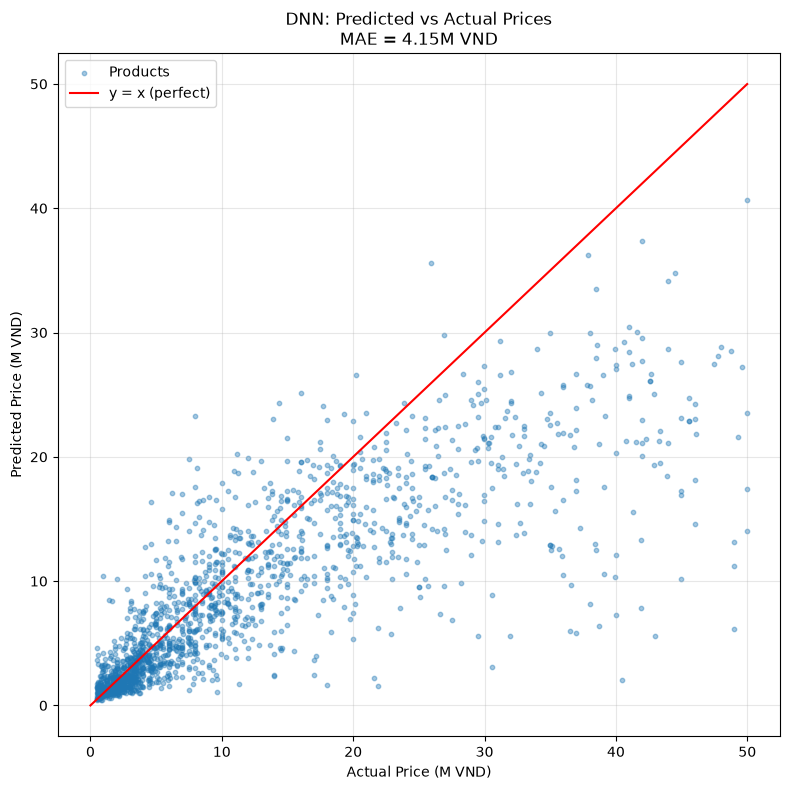

Scatter plot saved → models/dnn_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    all_actuals / 1_000_000,
    preds_vnd   / 1_000_000,
    alpha=0.4,
    s=10,
    label="Products",
)

max_val = max(all_actuals.max(), preds_vnd.max()) / 1_000_000
ax.plot([0, max_val], [0, max_val], color="red", linewidth=1.5, label="y = x (perfect)")

ax.set_xlabel("Actual Price (M VND)")
ax.set_ylabel("Predicted Price (M VND)")
ax.set_title(f"DNN: Predicted vs Actual Prices\nMAE = {mae / 1_000_000:.2f}M VND")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(models_dir / "dnn_scatter.png", dpi=150)
plt.show()
print("Scatter plot saved → models/dnn_scatter.png")